# 01 · Exploratory Data Analysis — WASSA CONV-turn

Foundational EDA for the turn-level empathy dataset (WASSA Track 2 / TRAC).
Each row is one conversational turn, annotated by third parties for four
continuous targets: **Emotion** (intensity), **EmotionalPolarity** (valence),
**Empathy**, and **SelfDisclosure**.

This notebook audits the data, handles the two missing values, inspects the
univariate distributions and their relationships, and checks for outliers and
structural issues. It is intended to run top-to-bottom with **Restart & Run
All**. The raw CSV is research-use-only and lives in `../data/` (see
`data/README.md`); it is not committed to the repository.


## 0 · Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Make the src/ helpers importable whether the notebook is run from notebooks/
# or from the repo root.
REPO_ROOT = Path.cwd()
if (REPO_ROOT / "src").is_dir():
    pass
elif (REPO_ROOT.parent / "src").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))
from data import load_convt, impute_selfdisclosure, TARGETS

# Display settings — make wide tables readable
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Plot styling — pick one and stick with it for a consistent deck
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Reproducibility — any random sampling we do should be the same on every run
RNG = np.random.default_rng(42)

In [2]:
# Load the data set.
# The `text` field contains backslash-escaped double quotes, so the CSV must be
# read with escapechar='\\'; load_convt() handles that. Targets are in TARGETS.
df = load_convt()
print(f"Loaded {df.shape[0]:,} turns x {df.shape[1]} columns")
print("Targets:", TARGETS)

Loaded 11,166 turns x 12 columns
Targets: ['Emotion', 'EmotionalPolarity', 'Empathy', 'SelfDisclosure']


## 1 · Warm-up
### 1.1 Sanity-check the load

In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print()
print("Dtype counts:")
print(df.dtypes.value_counts())
print()
print("Speaker labels present:", sorted(df["speaker"].unique()))

Rows: 11,166
Columns: 12

Dtype counts:
int64      4
str        4
float64    4
Name: count, dtype: int64

Speaker labels present: ['Person 1', 'Person 2']


### 1.2 Do the target values fall in their expected ranges?

In [4]:
print(f"Emotional polarity min: {df['EmotionalPolarity'].min()} and max: {df['EmotionalPolarity'].max()}")
print(f"Self Disclosure   min: {df['SelfDisclosure'].min()} and max: {df['SelfDisclosure'].max()}")
print(f"Empathy           min: {df['Empathy'].min()} and max: {df['Empathy'].max()}")
print(f"Emotion           min: {df['Emotion'].min()} and max: {df['Emotion'].max()}")

Emotional polarity min: 0.0 and max: 2.6667
Self Disclosure   min: 1.0 and max: 4.0
Empathy           min: 0.0 and max: 5.0
Emotion           min: 0.0 and max: 5.0


We examined the minimum and maximum values of each numerical feature and confirmed that all values fall within the expected ranges, with no irregularities. It is important to note that, although the original annotation scales for empathy, emotion intensity, emotional polarity, and self-disclosure are ordinal or categorical as defined in the annotation guidelines (Omitaomu et al., 2022), the WASSA 2024 shared task treats these features as continuous variables and uses the product-moment (Pearson) correlation as the primary evaluation metric (Giorgi et al., 2024). For my own research, I have the flexibility to follow the WASSA regression-based approach or, alternatively, to round the scores to the nearest integer and treat them as ordinal or categorical variables for additional analyses.

`Omitaomu, D., Tafreshi, S., Liu, T., Buechel, S., Callison-Burch, C., Eichstaedt, J., Ungar, L., & Sedoc, J. (2022). Empathic Conversations: A Multi-level Dataset of Contextualized Conversations. arXiv preprint arXiv:2205.12698.`

`Giorgi, S., Sedoc, J., Barriere, V., & Tafreshi, S. (2024). Findings of WASSA 2024 Shared Task on Empathy and Personality Detection in Interactions. In Proceedings of the 14th Workshop on Computational Approaches to Subjectivity, Sentiment, & Social Media Analysis (WASSA 2024), 369-379.`

In [5]:
# 1. Number of conversations per article
conv_counts = df.groupby('article_id')['conversation_id'].nunique().reset_index()
conv_counts.columns = ['article_id', 'num_conversations']
conv_counts = conv_counts.sort_values('num_conversations', ascending=False)

print("Article ID and number of associated conversations (first 10 rows):")
print(conv_counts.head(10).to_string(index=False))
if len(conv_counts) > 10:
    print(f"... and {len(conv_counts) - 10} more articles.\n")

# 2. Turns per conversation
turns_per_conv = df.groupby('conversation_id').size().reset_index(name='num_turns')

# Map each conversation to its article
conv_to_article = df[['conversation_id', 'article_id']].drop_duplicates()
merged = turns_per_conv.merge(conv_to_article, on='conversation_id')

# Average turns per conversation for each article
avg_turns = merged.groupby('article_id')['num_turns'].mean().reset_index()
avg_turns.columns = ['article_id', 'avg_turns_per_conversation']
avg_turns = avg_turns.sort_values('avg_turns_per_conversation', ascending=False)

print("Average number of turns per conversation, by article ID (first 10 rows):")
print(avg_turns.head(10).to_string(index=False))
if len(avg_turns) > 10:
    print(f"... and {len(avg_turns) - 10} more articles.\n")

# 3. Global min/max turns
global_min = turns_per_conv['num_turns'].min()
global_max = turns_per_conv['num_turns'].max()

print(f"Global minimum turns in any conversation: {global_min}")
print(f"Global maximum turns in any conversation: {global_max}")

# Count how many articles have fewer than 5 conversations
low_conv_articles = conv_counts[conv_counts['num_conversations'] < 5]

total_articles = len(conv_counts)
num_low = len(low_conv_articles)
percentage_low = (num_low / total_articles) * 100

print(f"\nTotal articles: {total_articles}")
print(f"Articles with fewer than 5 conversations: {num_low}")
print(f"Percentage: {percentage_low:.2f}%")

print("\nArticles with fewer than 5 conversations:")
print(low_conv_articles.sort_values('num_conversations', ascending=False).to_string(index=False))

Article ID and number of associated conversations (first 10 rows):
 article_id  num_conversations
          3                  5
          6                  5
          7                  5
          9                  5
         11                  5
         13                  5
         18                  5
         19                  5
         23                  5
         34                  5
... and 90 more articles.

Average number of turns per conversation, by article ID (first 10 rows):
 article_id  avg_turns_per_conversation
        281                     30.2000
        353                     28.4000
         49                     28.0000
        171                     27.4000
        336                     27.4000
        289                     27.0000
        201                     26.6000
        302                     26.2500
        375                     26.2000
        273                     25.2000
... and 90 more articles.

Global minimum turns in a

An examination of the distribution of conversations across articles reveals no significant anomalies. While 12 articles are associated with fewer than five conversations, this does not, on its own, constitute a statistical or practical irregularity. To determine whether these articles share any qualitative peculiarities (e.g., unusual content, length, or topic), a further manual inspection would be warranted. Note that this training split does **not** contain the source article text — only the conversational turns — so the preview below shows each low-conversation article's **first turn**, which is the closest proxy available here.

In [6]:
# 1. Re-compute conversation counts per article
conv_counts = df.groupby('article_id')['conversation_id'].nunique().reset_index()
conv_counts.columns = ['article_id', 'num_conversations']

# 2. Identify articles with fewer than 5 conversations
low_conv_article_ids = conv_counts[conv_counts['num_conversations'] < 5]['article_id'].tolist()
print(f"Number of articles with <5 conversations: {len(low_conv_article_ids)}")
print(f"Their article IDs: {low_conv_article_ids}\n")

# 3. This split has no article-text column, so preview the FIRST TURN (turn_id == 0)
#    of each low-conversation article as a stand-in.
first_turns = (
    df.sort_values(['article_id', 'conversation_id', 'turn_id'])
      .drop_duplicates(subset='article_id', keep='first')
)
low_conv_first_turns = first_turns[first_turns['article_id'].isin(low_conv_article_ids)]

# 4. Display a compact preview (first 200 characters) for each such article
print("First-turn preview for articles with fewer than 5 conversations:\n")
for _, row in low_conv_first_turns.iterrows():
    text = row['text']
    preview = text[:200] + "..." if len(text) > 200 else text
    print(f"Article ID: {row['article_id']}")
    print(f"First turn: {preview}\n")
    print("-" * 80)

Number of articles with <5 conversations: 12
Their article IDs: [31, 48, 58, 138, 150, 228, 247, 289, 302, 304, 326, 398]

First-turn preview for articles with fewer than 5 conversations:

Article ID: 31
First turn: Hello. What did you think of the article?

--------------------------------------------------------------------------------
Article ID: 48
First turn: what did you think about the article?

--------------------------------------------------------------------------------
Article ID: 58
First turn: I had never considered the zoo animals in countries like Venezuela. How sad.

--------------------------------------------------------------------------------
Article ID: 138
First turn: Hi there - the cruelty of kids towards other kids can be truly horrifying

--------------------------------------------------------------------------------
Article ID: 150
First turn: Hi there - I was very surprised to find out that China allowed women to become pilots at all

---------------------

### 1.3 Data Audit: Defining the semantics of each column
| Column | Semantic Type | Description |
|--------|---------------|-------------|
| id | Identifier | Like the name suggests, id is an identifier and it seems to be identifying each unique row |
| article_id | Identifier | Also an identifier, article_id is the unique identifier of each article that is used as a conversation starter |
| conversation_id | Identifier | Another identifier, it identifies each unique conversation based on an article |
| turn_id | Identifier | Identifies which turn we are looking at from the given conversation |
| speaker | Nominal Categorical | Two categories, `Person 1` and `Person 2` (note the space), alternating turns within a conversation |
| text | Text / unstructured | This is the content of each dialogue turn spoken by one of the two speakers |
| person_id_1 | Identifier | The ID of the first speaker in a given conversation |
| person_id_2 | Identifier | The ID of the second speaker in a given conversation |
| Emotion | Ordinal (treated as continuous) | Emotion **intensity** of the turn. Original per-annotator scale is ordinal (higher = stronger emotion). The CSV value is the average of the annotators' ratings (observed range 0-5), used as a continuous regression target. |
| EmotionalPolarity | Ordinal / valence (treated as continuous) | The **valence / polarity** of the turn's emotion (positive ↔ negative). The CSV holds 0-based averaged annotator ratings (observed range 0-~2.67). In this corpus — dyadic reactions to distressing news — **higher values correspond to more *negative* emotion**: turns containing words like *sad/terrible/awful* average ≈1.8-1.9, whereas *happy/glad/great* average ≈0.2-0.8 (verified in §3.1 below; overall mean ≈1.29). So the axis runs positive (low) → negative (high). |
| Empathy | Ordinal (treated as continuous) | Level of expressed empathy in the turn (higher = more empathic). The CSV contains the average of the annotators' ratings (observed range 0-5), used as a continuous target. |
| SelfDisclosure | Ordinal (treated as continuous) | Degree of personal self-disclosure in the turn (higher = more disclosure). The CSV contains the average of the annotators' ratings (observed range 1-4). |


## 2 · Missing Data

In [7]:
missing = (
    df.isna().sum()
    .loc[lambda s: s > 0]
    .sort_values(ascending=False)
    .to_frame("n_missing")
    .assign(pct_missing=lambda d: 100 * d["n_missing"] / len(df))
)
missing

,n_missing,pct_missing
SelfDisclosure,2,0.0179


Given that SelfDisclosure is a property of the individual speaker, missing values can be imputed using the mean of that speaker's observed SelfDisclosure scores across their conversational turns. The imputation resolves the speaker to a person via the `speaker` label — which is `Person 1` / `Person 2` **with a space** — and falls back to the global mean only for a person with no observed value anywhere.

In [8]:
# Impute the two missing SelfDisclosure values with each speaker's own mean.
# (Implementation lives in src/data.py so the notebook and the baseline share it.)
before = int(df["SelfDisclosure"].isna().sum())
missing_rows = df.index[df["SelfDisclosure"].isna()]

df = impute_selfdisclosure(df)

print(f"Missing SelfDisclosure before: {before}")
print(f"Missing SelfDisclosure after : {int(df['SelfDisclosure'].isna().sum())}")
print(f"Global mean (for comparison) : {df['SelfDisclosure'].mean():.4f}")
print("Imputed (speaker-specific) values:",
      [round(v, 4) for v in df.loc[missing_rows, 'SelfDisclosure'].tolist()])

Missing SelfDisclosure before: 2
Missing SelfDisclosure after : 0
Global mean (for comparison) : 1.9326
Imputed (speaker-specific) values: [1.8458, 1.7883]


## 3 · Univariate Analysis & Transformations

In [9]:
features = TARGETS  # ['Emotion', 'EmotionalPolarity', 'Empathy', 'SelfDisclosure']
print(df[features].describe())

          Emotion  EmotionalPolarity     Empathy  SelfDisclosure
count 11,166.0000        11,166.0000 11,166.0000     11,166.0000
mean       2.2197             1.2865      2.0862          1.9326
std        0.8220             0.6099      0.9203          0.6377
min        0.0000             0.0000      0.0000          1.0000
25%        1.6667             1.0000      1.3333          1.3333
50%        2.0000             1.3333      2.0000          2.0000
75%        2.6667             2.0000      2.6667          2.3333
max        5.0000             2.6667      5.0000          4.0000


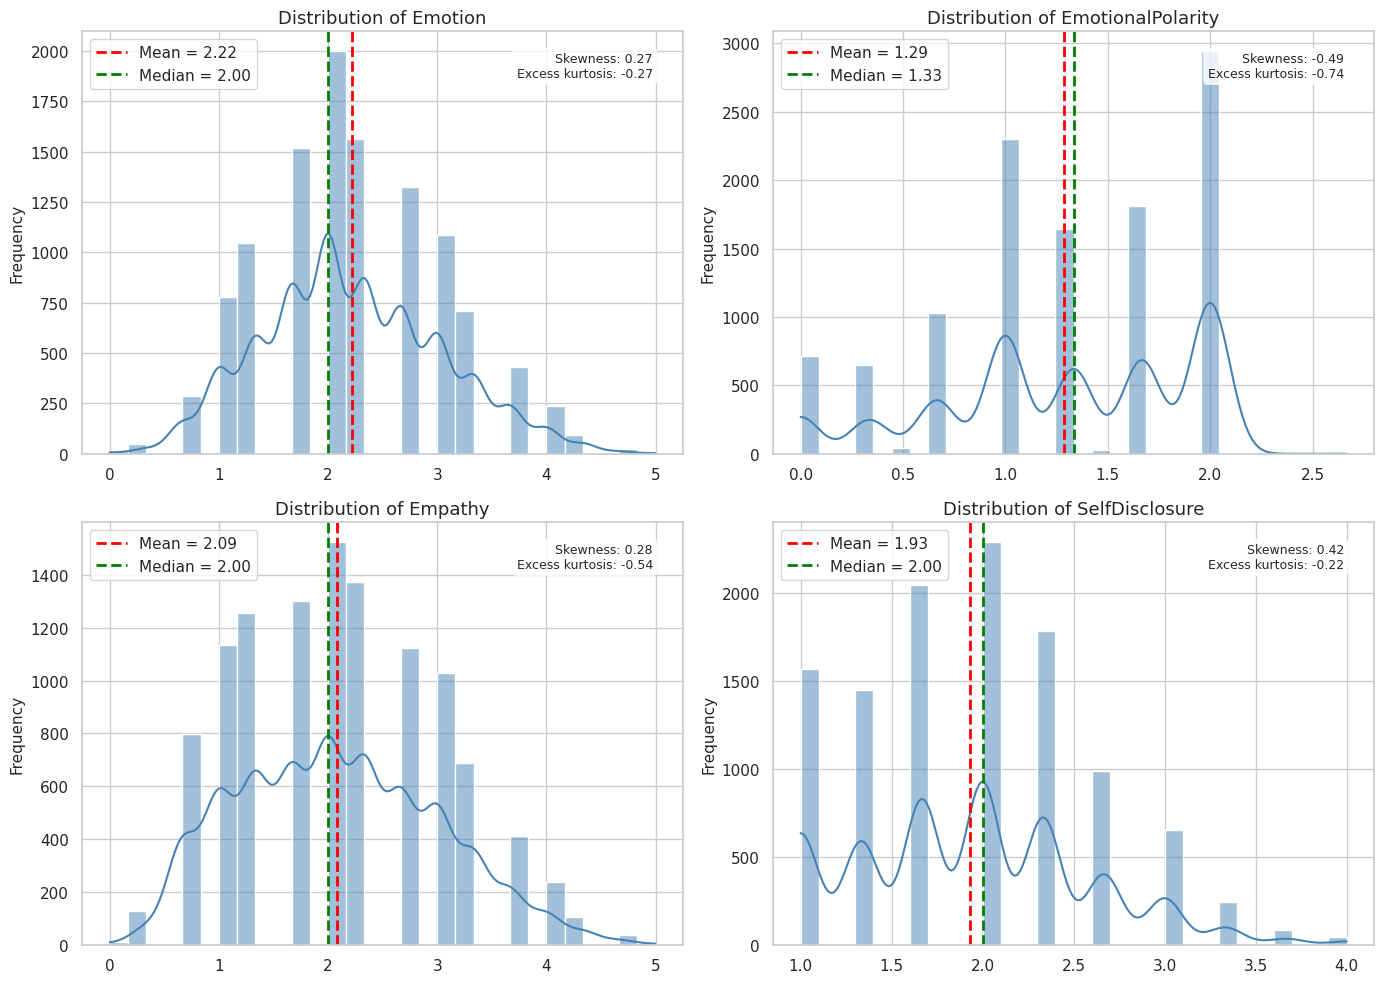

In [10]:
from scipy.stats import skew, kurtosis

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feat in zip(axes.flat, features):
    data = df[feat].dropna()

    # Histogram + KDE
    sns.histplot(data, kde=True, ax=ax, bins=30, color='steelblue')

    # Statistics
    mean_val = data.mean()
    median_val = data.median()
    skew_val = skew(data)
    kurt_val = kurtosis(data)  # excess kurtosis (0 = normal)

    # Vertical lines for mean (red) and median (green)
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median = {median_val:.2f}')

    # Text box with skewness and (excess) kurtosis
    stats_text = f"Skewness: {skew_val:.2f}\nExcess kurtosis: {kurt_val:.2f}"
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes,
            verticalalignment='top', horizontalalignment='right',
            fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.set_title(f'Distribution of {feat}')
    ax.legend(loc='upper left')
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

The univariate analysis of the four target variables (Emotion, EmotionalPolarity, Empathy, SelfDisclosure) revealed that, for each feature, the mean and median were close, skewness was below |1|, and excess kurtosis remained within |1|. These indicators suggest approximately symmetric, light-tailed distributions. Consequently, no power or log transformation was applied, and the targets are used on their original scales. (No standardisation is performed in this notebook; if a downstream model needs comparable input scales, scaling should be fit on the training split only and applied to dev/test to avoid leakage.)

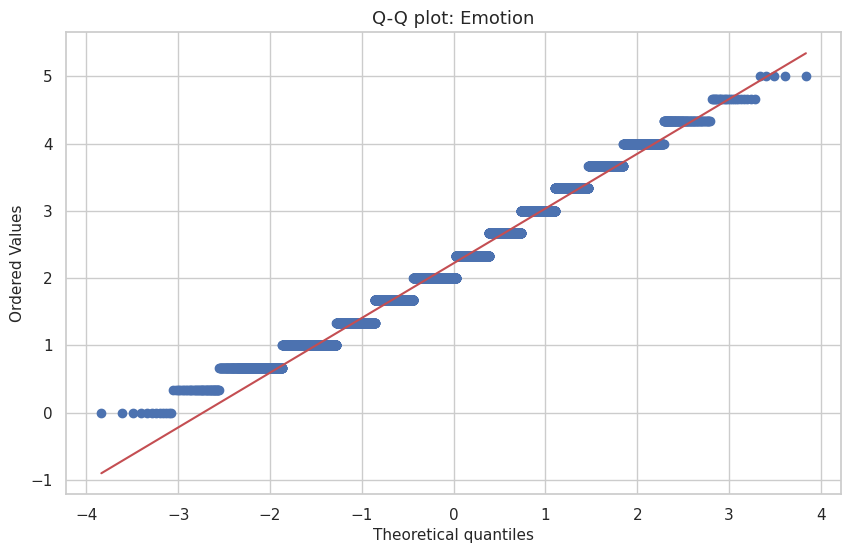

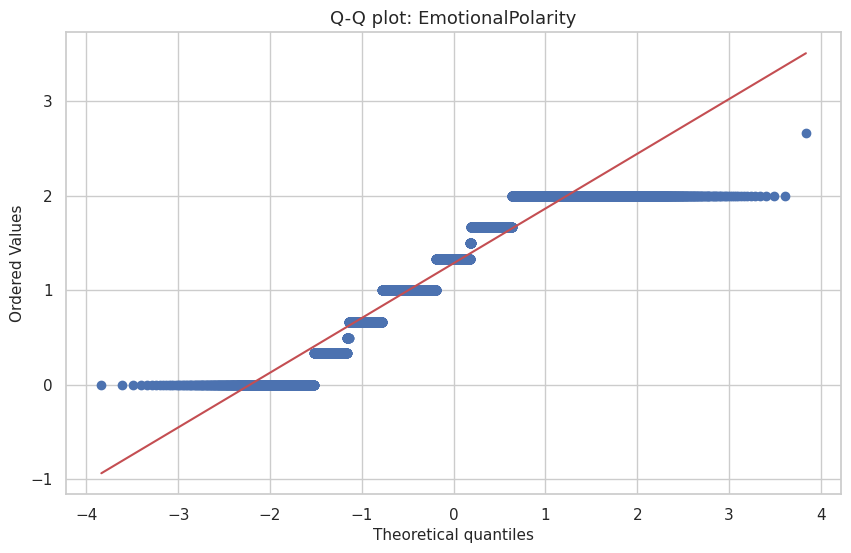

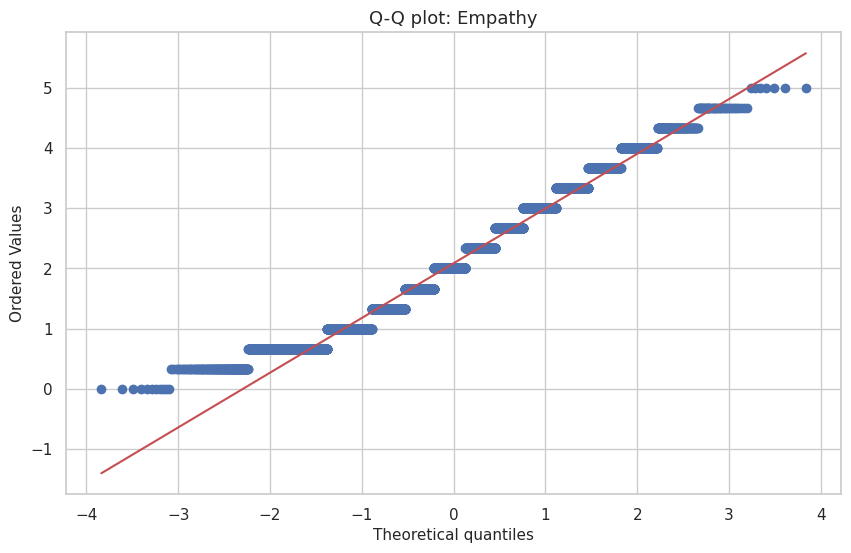

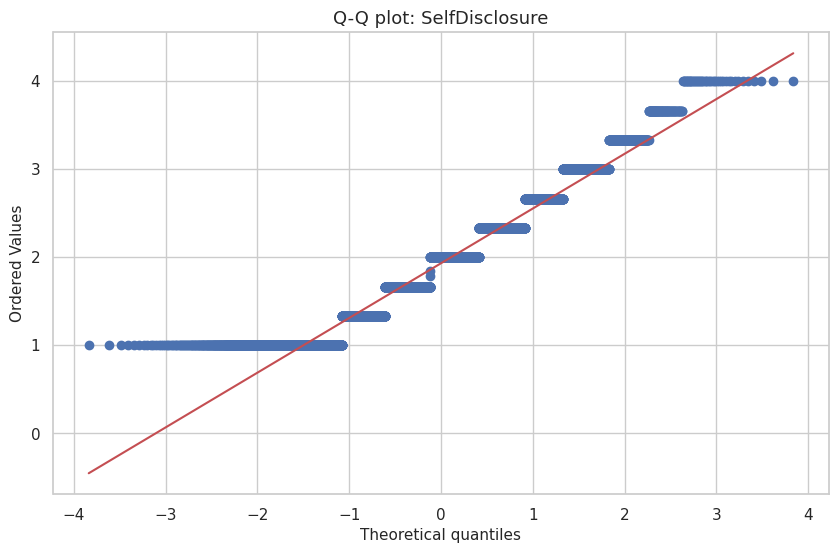

In [11]:
for feat in features:
    stats.probplot(df[feat].dropna(), dist='norm', plot=plt)
    plt.title(f'Q-Q plot: {feat}')
    plt.show()

The four targets are provided on different but overlapping numeric ranges: Emotion and Empathy span roughly **0-5**, EmotionalPolarity spans roughly **0-2.67** (a valence axis running positive at the low end → negative at the high end, confirmed just below), and SelfDisclosure spans **1-4**. Each value is the average of the annotators' ordinal ratings, which is why fractional scores (multiples of ⅓ and ½) appear. These range differences do not affect the ordinal relationships or the modelling approach, as all variables are treated as continuous scores; they only matter for any model that expects comparably-scaled inputs, where scaling would be fit on the training split.

### 3.1 Which direction is EmotionalPolarity?

The scale's orientation is not obvious from the numbers alone, so we check it
directly: compare the mean EmotionalPolarity of turns containing clearly
negative words against turns containing clearly positive words.

In [12]:
neg_words = ['sad', 'terrible', 'awful', 'horrible']
pos_words = ['happy', 'glad', 'great', 'wonderful']

def mean_polarity(word):
    mask = df['text'].str.contains(rf'\b{word}\b', case=False, regex=True)
    return df.loc[mask, 'EmotionalPolarity'].mean(), int(mask.sum())

print(f"Overall mean EmotionalPolarity: {df['EmotionalPolarity'].mean():.3f}\n")
print("Negative-word turns:")
for w in neg_words:
    mp, n = mean_polarity(w)
    print(f"  {w:10s} mean={mp:.3f}  (n={n})")
print("Positive-word turns:")
for w in pos_words:
    mp, n = mean_polarity(w)
    print(f"  {w:10s} mean={mp:.3f}  (n={n})")
print("\n=> Higher EmotionalPolarity co-occurs with NEGATIVE content: "
      "the axis runs positive (low) -> negative (high).")

Overall mean EmotionalPolarity: 1.287

Negative-word turns:
  sad        mean=1.836  (n=530)
  terrible   mean=1.849  (n=171)
  awful      mean=1.918  (n=65)
  horrible   mean=1.856  (n=65)
Positive-word turns:
  happy      mean=0.759  (n=36)
  glad       mean=0.741  (n=54)
  great      mean=0.654  (n=258)
  wonderful  mean=0.190  (n=7)

=> Higher EmotionalPolarity co-occurs with NEGATIVE content: the axis runs positive (low) -> negative (high).


## 4 · Overview of Relationships

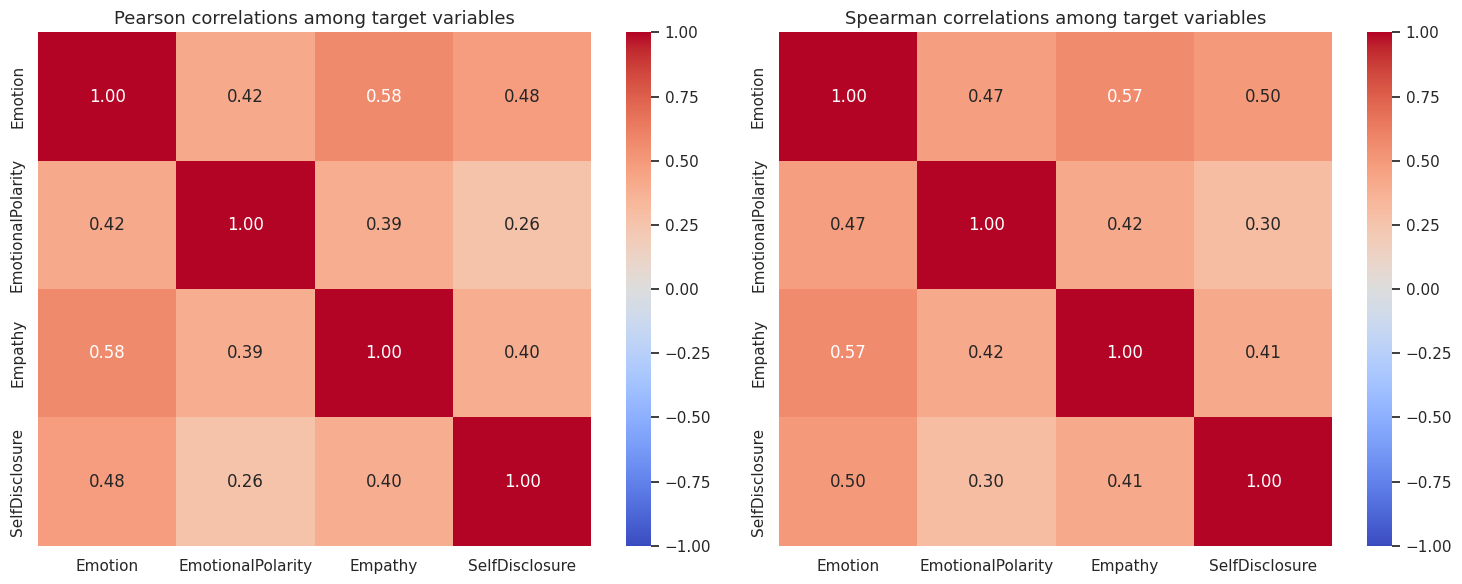

Pearson  off-diagonal range: 0.26 to 0.58
Spearman off-diagonal range: 0.30 to 0.57


In [13]:
# Show both correlations, each labelled correctly.
#   Pearson  = WASSA's primary evaluation metric (linear association).
#   Spearman = rank-based, robust to the ordinal origin of the scores.
pearson = df[features].corr(method='pearson')
spearman = df[features].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(pearson, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Pearson correlations among target variables')
sns.heatmap(spearman, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Spearman correlations among target variables')
plt.tight_layout()
plt.show()

# Off-diagonal ranges, for the write-up
def offdiag_range(corr):
    m = corr.to_numpy().copy()
    np.fill_diagonal(m, np.nan)
    return np.nanmin(m), np.nanmax(m)

p_lo, p_hi = offdiag_range(pearson)
s_lo, s_hi = offdiag_range(spearman)
print(f"Pearson  off-diagonal range: {p_lo:.2f} to {p_hi:.2f}")
print(f"Spearman off-diagonal range: {s_lo:.2f} to {s_hi:.2f}")

All four targets are **positively and moderately** correlated with one another, and no pair is so highly correlated as to be redundant. Pearson correlations (WASSA's primary metric) run from roughly **0.26 to 0.58**, with the strongest link between Emotion and Empathy; the rank-based Spearman correlations tell the same story (≈ **0.30 to 0.57**). This confirms that each variable captures a distinct but related aspect of conversational affect.

## 5 · Looking for Outliers

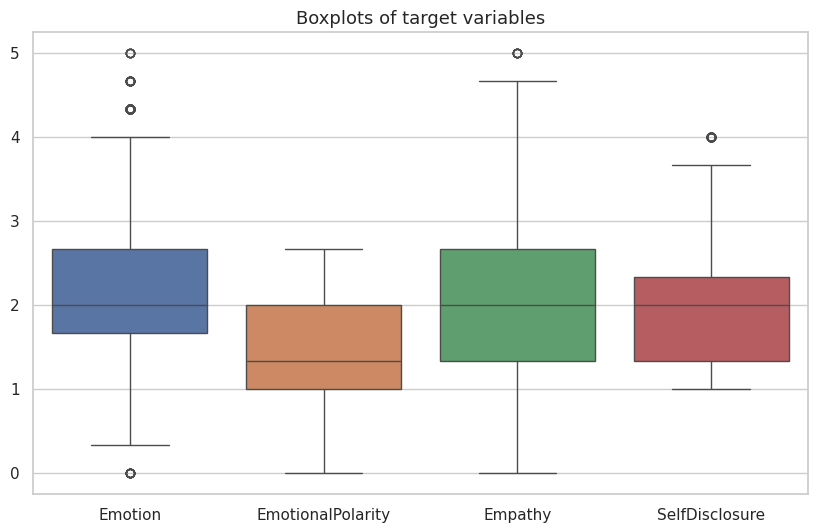

Emotion: IQR bounds = [0.167, 4.167], outliers = 135
  Distinct outlier values: [np.float64(0.0), np.float64(4.3333), np.float64(4.6667), np.float64(5.0)]
EmotionalPolarity: IQR bounds = [-0.500, 3.500], outliers = 0
Empathy: IQR bounds = [-0.667, 4.667], outliers = 7
  Distinct outlier values: [np.float64(5.0)]
SelfDisclosure: IQR bounds = [-0.167, 3.833], outliers = 47
  Distinct outlier values: [np.float64(4.0)]


In [14]:
# 1. Boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[features])
plt.title('Boxplots of target variables')
plt.show()

# 2. IQR outlier detection
outlier_summary = {}
for feat in features:
    data = df[feat].dropna()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    outlier_summary[feat] = {
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'num_outliers': len(outliers),
    }
    print(f"{feat}: IQR bounds = [{lower_bound:.3f}, {upper_bound:.3f}], outliers = {len(outliers)}")
    if len(outliers) > 0:
        print(f"  Distinct outlier values: {sorted(outliers.unique())}")

Using the standard IQR (1.5×) rule, several observations in Emotion, Empathy, and SelfDisclosure were flagged as statistical outliers (e.g., values of 0 and 5 in Emotion, 5 in Empathy, and 4 in SelfDisclosure). However, all these values fall within the theoretical limits of the respective scales (0-5 for Emotion and Empathy, 1-4 for SelfDisclosure). Because the variables are bounded and the flagged points represent genuine extreme ratings (e.g., no emotion or maximum empathy), no data points were removed or corrected. The same reasoning applies to the value 2.667 in EmotionalPolarity, which, though not flagged, is also a legitimate average of the annotators' ratings.

In [15]:
# 1. Within each conversation, person_id_1 != person_id_2 (no one talks to themselves)
same_person = []
for conv_id, group in df.groupby('conversation_id'):
    p1 = group['person_id_1'].iloc[0]
    p2 = group['person_id_2'].iloc[0]
    if p1 == p2:
        same_person.append(conv_id)
if same_person:
    print(f"WARNING: Conversations with same person ID for both roles: {same_person}")
else:
    print("No conversation has the same person as both speaker 1 and speaker 2. Good.")

# 2. Does any ID appear as both person_id_1 and person_id_2 across the dataset?
ids_in_p1 = set(df['person_id_1'].unique())
ids_in_p2 = set(df['person_id_2'].unique())
common_ids = ids_in_p1.intersection(ids_in_p2)
if common_ids:
    print(f"\nNote: {len(common_ids)} person IDs appear both as person_id_1 and person_id_2 "
          f"in different conversations.")
    print("This is not an error - those individuals were the first speaker in some "
          "conversations and the second in others.")
else:
    print("\nNo person ID appears in both roles across all conversations.")

# 3. Turns per person. Resolve the actual speaker's ID using the (space-containing)
#    'Person 1' / 'Person 2' labels.
def get_speaker_id(row):
    if row['speaker'] == 'Person 1':
        return row['person_id_1']
    if row['speaker'] == 'Person 2':
        return row['person_id_2']
    return None

df['speaker_id'] = df.apply(get_speaker_id, axis=1)
assert df['speaker_id'].notna().all(), "Unexpected speaker label produced a null speaker_id"

turns_per_person = (
    df.groupby('speaker_id').size().reset_index(name='num_turns')
      .sort_values('num_turns', ascending=False)
)

print("\nTurn counts per speaker (top 10):")
print(turns_per_person.head(10).to_string(index=False))

print(f"\nTotal number of unique speakers: {len(turns_per_person)}")
print(f"Minimum turns per speaker: {turns_per_person['num_turns'].min()}")
print(f"Maximum turns per speaker: {turns_per_person['num_turns'].max()}")
print(f"Mean turns per speaker: {turns_per_person['num_turns'].mean():.2f}")

No conversation has the same person as both speaker 1 and speaker 2. Good.

Note: 45 person IDs appear both as person_id_1 and person_id_2 in different conversations.
This is not an error - those individuals were the first speaker in some conversations and the second in others.

Turn counts per speaker (top 10):
speaker_id  num_turns
      p024       1024
      p035        865
      p029        795
      p022        782
      p068        755
      p030        655
      p062        617
      p019        486
      p039        402
      p010        354

Total number of unique speakers: 71
Minimum turns per speaker: 10
Maximum turns per speaker: 1024
Mean turns per speaker: 157.27


## 6 · Concluding Remarks on Data Analysis

The systematic data audit and exploratory analysis have provided a thorough understanding of the dataset's structure, quality, and inherent characteristics. Only two missing values were identified (in the SelfDisclosure column), and these were imputed using speaker-specific means — a method justified by the nature of self-disclosure as an individual-level property. All numerical target variables (Emotion, EmotionalPolarity, Empathy, SelfDisclosure) fall within their expected theoretical bounds, and although the IQR rule flagged a number of extreme values (e.g., 0, 5, 4), these correspond to legitimate and informative endpoints of the original rating scales. No data points were removed or altered beyond the minimal imputation, preserving the full range of human annotations. Univariate distributions are approximately symmetric with low skewness and light tails, indicating that power transformations are unnecessary, and no standardisation was applied at this stage. The four targets are moderately, positively correlated: Pearson correlations (WASSA's primary metric) range from about **0.26 to 0.58** and the rank-based Spearman correlations agree (≈ 0.30 to 0.57), confirming that each captures a distinct yet related aspect of conversational affect. Overall, the dataset is of high quality, contains no systematic errors, and is well-suited for the subsequent development of natural-language-processing models aimed at predicting empathy from dialogue turns.